In [1]:
!cd ~/c/iu9-sql-compiler/ && python -m research.fuzz.cost_stats \
    --cli build-release/bin/sql \
    --data-dir test/static/executor/test_data \
    --count 400 --repeats 5 \
    --out research/cost-stats.csv

collected=25 attempted=25 skipped=0
collected=50 attempted=50 skipped=0
collected=75 attempted=75 skipped=0
collected=100 attempted=100 skipped=0
collected=125 attempted=125 skipped=0
collected=150 attempted=150 skipped=0
collected=175 attempted=175 skipped=0
collected=200 attempted=200 skipped=0
collected=225 attempted=225 skipped=0
collected=250 attempted=250 skipped=0
collected=275 attempted=275 skipped=0
collected=300 attempted=300 skipped=0
collected=325 attempted=325 skipped=0
collected=350 attempted=350 skipped=0
collected=375 attempted=375 skipped=0
collected=400 attempted=400 skipped=0
done: collected=400 attempted=400 skipped=0 -> research/cost-stats.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('cost-stats.csv')
df['exec_ms'] = df['exec_us'] / 1e3
print(f'{len(df)} samples')
df[['seed', 'plan_cost', 'exec_us', 'rows']].describe()

400 samples


,seed,plan_cost,exec_us,rows
count,400.000000,4.000000e+02,4.000000e+02,400.00000
mean,199.500000,3.293322e+07,3.063712e+04,3446.78750
std,115.614301,2.369086e+08,2.124881e+05,24278.01832
min,0.000000,3.660000e+02,1.220000e+02,0.00000
25%,99.750000,2.987250e+03,1.787500e+02,2.00000
50%,199.500000,4.735800e+04,3.300000e+02,5.00000
75%,299.250000,6.809730e+05,1.214250e+03,30.00000
max,399.000000,2.984422e+09,2.956573e+06,384231.00000


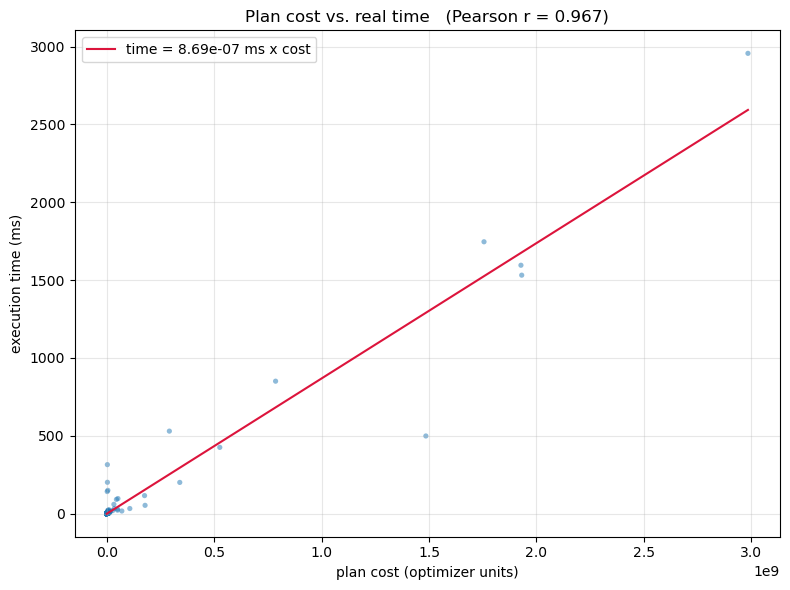

In [3]:
cost = df['plan_cost'].to_numpy(dtype=float)
time_ms = df['exec_ms'].to_numpy(dtype=float)

# Proportional fit through the origin: time = slope * cost.
slope = float(np.sum(cost * time_ms) / np.sum(cost * cost))
r = float(np.corrcoef(cost, time_ms)[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost, time_ms, s=14, alpha=0.5, edgecolor='none')
xs = np.array([0.0, cost.max()])
ax.plot(xs, slope * xs, color='crimson', lw=1.5,
        label=f'time = {slope:.3g} ms x cost')
ax.set_xlabel('plan cost (optimizer units)')
ax.set_ylabel('execution time (ms)')
ax.set_title(f'Plan cost vs. real time   (Pearson r = {r:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

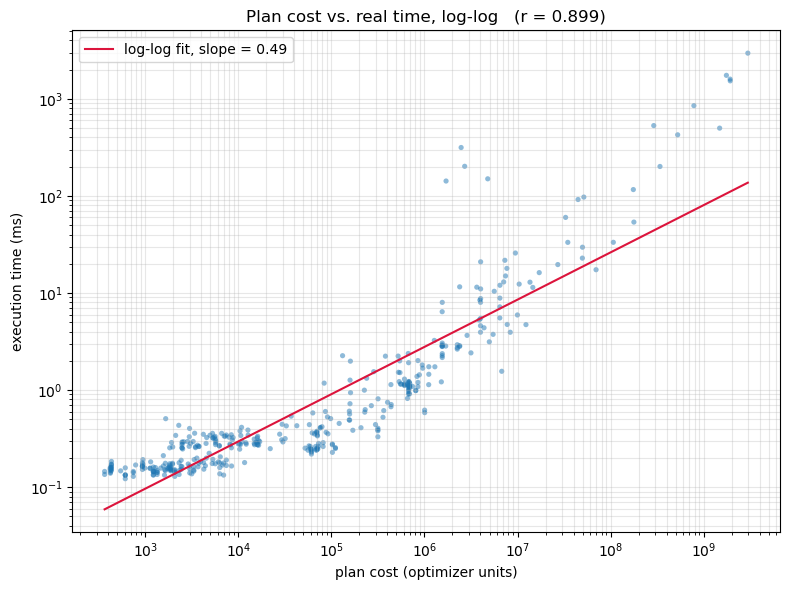

In [4]:
mask = (cost > 0) & (time_ms > 0)
lc = np.log10(cost[mask])
lt = np.log10(time_ms[mask])

a, b = np.polyfit(lc, lt, 1)
r_log = float(np.corrcoef(lc, lt)[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[mask], time_ms[mask], s=14, alpha=0.5, edgecolor='none')
xs = np.array([cost[mask].min(), cost[mask].max()])
ax.plot(xs, 10**b * xs**a, color='crimson', lw=1.5,
        label=f'log-log fit, slope = {a:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('plan cost (optimizer units)')
ax.set_ylabel('execution time (ms)')
ax.set_title(f'Plan cost vs. real time, log-log   (r = {r_log:.3f})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
print(f'samples              : {len(df)}')
print(f'cost range           : {int(cost.min())} .. {int(cost.max())}')
print(f'time range (ms)      : {time_ms.min():.3f} .. {time_ms.max():.1f}')
print(f'Pearson r (linear)   : {r:.3f}')
print(f'log-log slope        : {a:.3f}   (1.0 == perfectly proportional)')
print(f'log-log correlation  : {r_log:.3f}')

samples              : 400
cost range           : 366 .. 2984422200
time range (ms)      : 0.122 .. 2956.6
Pearson r (linear)   : 0.967
log-log slope        : 0.487   (1.0 == perfectly proportional)
log-log correlation  : 0.899
